In [222]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import scipy.io as sio
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

from monsoonbench.spatial.regions import get_india_outline

import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from plot_config import params, contourLevels, colormap, savefig_format, SMALL_SIZE, MEDIUM_SIZE, LARGE_SIZE

# Apply plot settings
plt.rcParams.update(params)


# Your plotting code here...

In [223]:
# Configuration parameters
model_str = ['Climatology', 'IFS', 'AIFS', 'FuXi', 'Graphcast', 'GenCast', 'FuXi S2S', 'NGCM']
#dummy_str = ['GenCast']
yr_ar = np.arange(2019, 2025)  # [2019:2024]


In [224]:

polygon_col = np.array([49, 130, 189]) / 256
map_col = 0.3*np.array([1, 1, 1])

# Define Core Monsoon Zone polygon
polygon1_lon = np.array([86, 74, 74, 70, 70, 82, 82, 86, 86])
polygon1_lat = np.array([18, 18, 22, 22, 30, 30, 26, 26, 18])


In [225]:
# def get_india_outline():
#     """
#     Get India outline coordinates. First try to load from shapefile, 
#     then fall back to simplified coordinates.
#     """
#     try:
#         # Try to load India shapefile - use the specified path first
#         shapefile_paths = [
#             '../fig_data/ind_map_shapefile/india_shapefile.shp',
#             'india_shapefile.shp'
#         ]
        
#         for path in shapefile_paths:
#             try:
#                 import geopandas as gpd
#                 india_gdf = gpd.read_file(path)
#                 # Extract boundary coordinates
#                 boundaries = []
#                 for geom in india_gdf.geometry:
#                     if hasattr(geom, 'exterior'):
#                         coords = list(geom.exterior.coords)
#                         lon_coords = [coord[0] for coord in coords]
#                         lat_coords = [coord[1] for coord in coords]
#                         boundaries.append((lon_coords, lat_coords))
#                     elif hasattr(geom, 'geoms'):
#                         for sub_geom in geom.geoms:
#                             if hasattr(sub_geom, 'exterior'):
#                                 coords = list(sub_geom.exterior.coords)
#                                 lon_coords = [coord[0] for coord in coords]
#                                 lat_coords = [coord[1] for coord in coords]
#                                 boundaries.append((lon_coords, lat_coords))
#                 return boundaries
#             except:
#                 continue
#     except:
#         pass
    
#     return [(india_lon, india_lat)]

# print("India outline function defined")

In [226]:
# Load data from MAT files
# Define file paths
file_15day = "mae_far_mr_15_day_2019_2024 (1).mat"
print("Loading 15-day data...")
data_15 = sio.loadmat(file_15day)

    
    # Extract coordinate data (assuming they're in the MAT files)
    # Check what variables are available in the MAT files
print("Available variables in 15-day file:", [key for key in data_15.keys() if not key.startswith('__')])
    
    # Extract coordinates - adjust variable names as needed based on your MAT file structure
if 'lon' in data_15:
    lons = data_15['lon'].flatten()
    lats = data_15['lat'].flatten()
else:
    # If coordinates not found, use default range - you may need to adjust this
    print("Warning: Coordinates not found in MAT file, using default range")
    lon = np.arange(70, 101, 4)
    lat = np.arange(8, 39, 4)

    # Extract MAE data - adjust variable names as needed

mae_avg = data_15['mae_avg']
mae_cmz = data_15['mae_cmz_mean']
std_er = data_15['std_er']
far = data_15['false_alarm']
far_cmz = data_15['far_cmz_mean']
mr = data_15['miss_rate']
mr_cmz = data_15['mr_cmz_mean']

    

Loading 15-day data...
Available variables in 15-day file: ['csi_cmz_mean', 'csi_yr', 'ets_cmz_mean', 'ets_yr', 'false_alarm', 'far_cmz_mean', 'lat', 'lon', 'mae_avg', 'mae_cmz_mean', 'miss_rate', 'model_str', 'mr_cmz_mean', 'std_er']


In [227]:
def reformat_csv_as_grids(df, metric):
    
    model_vals = df['model'].unique()

    lat_to_idx = {v: i for i, v in enumerate(lats)}
    lon_to_idx = {v: i for i, v in enumerate(lons)}

    # output dict
    data_dict = {}

    for model in model_vals:
        sub = df[df['model'] == model]

        grid = np.full((len(lats), len(lons)), np.nan)

        for _, row in sub.iterrows():
            i = lat_to_idx[row['lat']]
            j = lon_to_idx[row['lon']]
            grid[i, j] = row[metric]

        data_dict[model] = grid

    ordered_dict = {m: data_dict[m] for m in model_str if m in data_dict}
    ordered_dict["None"] = np.full((len(lats), len(lons)), np.nan)

    return ordered_dict

In [228]:
import pandas as pd
df = pd.read_csv("outputs/fig_7_through_12_data_recreation.csv")
df = df.loc[df["horizon"] == 15]
df.head(10)

,Unnamed: 0,lat,lon,Mean MAE,model,horizon,Miss Rate,False Alarm Rate
0,0,8.0,76.0,4.500000,Climatology,15,36.0,19.5
1,1,8.0,80.0,30.500000,Climatology,15,100.0,1.2
2,2,12.0,76.0,5.333333,Climatology,15,37.5,18.6
3,3,12.0,80.0,7.750000,Climatology,15,62.5,14.8
4,4,16.0,72.0,4.166667,Climatology,15,25.0,15.6
5,5,16.0,76.0,4.833333,Climatology,15,33.3,25.0
6,6,16.0,80.0,6.000000,Climatology,15,38.5,22.6
7,7,16.0,84.0,8.666667,Climatology,15,59.3,25.9
8,8,20.0,68.0,8.600000,Climatology,15,58.3,10.7
9,9,20.0,72.0,5.600000,Climatology,15,52.0,12.5


In [229]:
mae_avg = reformat_csv_as_grids(df=df, metric="Mean MAE")
mae_avg = np.stack([val for key, val in mae_avg.items()], axis=0)

far = reformat_csv_as_grids(df=df, metric="False Alarm Rate")
far = np.stack([val for key, val in far.items()], axis=0)


mr = reformat_csv_as_grids(df=df, metric="Miss Rate")
mr = np.stack([val for key, val in mr.items()], axis=0)



In [230]:
# General font sizes for all plots

SMALL_SIZE = 6 # Smaller text inside the grid boxes or legend
MEDIUM_SIZE = 7 # Medium text size for panel text (Model name and CMZ numbers)
BIGGER_SIZE = 8 # Larger text size for main titles

In [231]:
# Define plotting parameters
map_lw = 0.5
polygon_lw = 1
title_fontsize = 7
tick_length = 2.5
tick_width = 1
label_fontsize = 5

# Define colors for MAE, FAR, and MR (matching your bar chart colors)
mae_col = np.array([217, 95, 14]) / 256  # Orange
far_col = np.array([49, 130, 189]) / 256  # Blue
mr_col = np.array([188, 189, 220]) / 256  # Light purple

# ...existing code...

def create_map_panel_colored_stats(ax, data, lon, lat, model_idx, model_name, 
                                #   mae_cmz_mean, std_er, far_cmz_mean, mr_cmz_mean,
                                  data_type='MAE', vmin=0, vmax=15, cmap='YlOrRd', n_colors=6, 
                                  show_ylabel=True, show_xlabel=True, title=None):
    """
    Create a map panel with colored statistics text for MAE, FAR, and MR
    """
    
    # Create meshgrid for plotting
    lon_edges = np.concatenate([lon - (lon[1]-lon[0])/2, [lon[-1] + (lon[1]-lon[0])/2]])
    lat_edges = np.concatenate([lat - (lat[1]-lat[0])/2, [lat[-1] + (lat[1]-lat[0])/2]])
    LON_edges, LAT_edges = np.meshgrid(lon_edges, lat_edges)
    
    # Plot the main data
    # plt_ar = data[:, :, model_idx]
    # cmap = plt.cm.get_cmap(cmap, n_colors)
    # masked_data = np.ma.masked_invalid(plt_ar.T)
    plt_ar = data[model_idx, :, :]
    cmap = plt.cm.get_cmap(cmap, n_colors)
    masked_data = np.ma.masked_invalid(plt_ar)
    
    # Use pcolormesh for proper grid cell alignment
    im = ax.pcolormesh(LON_edges, LAT_edges, masked_data, 
                       cmap=cmap, vmin=vmin, vmax=vmax, shading='flat')
    
    # Add India map outline
    india_boundaries = get_india_outline('/Users/charlieeden/Desktop/Spring 2026/ds_clinic/monsoon-benchmark_data/ind_map_shpfile/india_shapefile.shp')
    for boundary in india_boundaries:
        india_lon, india_lat = boundary
        ax.plot(india_lon, india_lat, color='black', linewidth=map_lw)
    
    # Add polygon for Core Monsoon Zone
    polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                     fill=False, edgecolor='black', linewidth=polygon_lw)
    ax.add_patch(polygon)
    
    # Add model name text in top-right
    ax.text(0.95, 0.95, model_name, transform=ax.transAxes,
            horizontalalignment='right', verticalalignment='top',
            color='black', fontsize=MEDIUM_SIZE, fontweight='normal')

    # NO GRID VALUES - Remove the grid value text completely
    
    # Set axis limits and ticks
    ax.set_xlim([lon[0]-4, 100])
    ax.set_ylim([lat[0]-4, lat[-1]+4])
    
    # Create tick labels
    yticks = np.arange(lat[0]-2, lat[-1]+3, 8)
    yticklabels = [f"{int(y)}°N" if i % 1 == 0 else "" for i, y in enumerate(yticks)]
    ax.set_yticks(yticks)
    if show_ylabel:
        ax.set_yticklabels(yticklabels)
    else:
        ax.set_yticklabels([])
    
    xticks = np.arange(lon[0]-2, lon[-1]+3, 8)
    xticklabels = [f"{int(x)}°E" if i % 1 == 0 else "" for i, x in enumerate(xticks)]
    ax.set_xticks(xticks)
    if show_xlabel:
        ax.set_xticklabels(xticklabels)
    else:
        ax.set_xticklabels([])
    
    # Add ONLY the relevant metric text based on data_type
    # Convert numpy arrays to scalars
    # mae_val = mae_cmz_mean.flatten()[model_idx] if hasattr(mae_cmz_mean, 'flatten') else mae_cmz_mean[model_idx]
    # std_val = std_er.flatten()[model_idx] if hasattr(std_er, 'flatten') else std_er[model_idx]
    # far_val = far_cmz_mean.flatten()[model_idx] if hasattr(far_cmz_mean, 'flatten') else far_cmz_mean[model_idx]
    # mr_val = mr_cmz_mean.flatten()[model_idx] if hasattr(mr_cmz_mean, 'flatten') else mr_cmz_mean[model_idx]
    
    # # Show only the relevant metric for each figure type
    # if data_type == 'MAE':
    #     metric_text = f'MAE: {mae_val:.1f}±{std_val:.1f}'
    #     text_color = 'black'
    # elif data_type == 'FAR':
    #     metric_text = f'FAR: {far_val:.1f}%'
    #     text_color = 'black'    
    # elif data_type == 'MR':
    #     metric_text = f'MR: {mr_val:.1f}%'
    #     text_color = 'black'
    # else:
    #     metric_text = f'MAE: {mae_val:.1f}±{std_val:.1f}'
    #     text_color = 'black'

    # Position the single metric text
    # ax.text(0.96, 0.04, metric_text, transform=ax.transAxes,
    #         color=text_color, verticalalignment='bottom', 
    #         horizontalalignment='right', fontweight='normal', fontsize=MEDIUM_SIZE)
    
    # Remove grid lines
    ax.grid(False)
    ax.set_axisbelow(False)
    ax.tick_params('both', length=tick_length, width=tick_width, which='major')
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.tick_params(axis='y', which='minor', left=False, right=False)

    if title:
        ax.text(0.02, 1.02, title, transform=ax.transAxes, 
                verticalalignment='bottom', fontsize=BIGGER_SIZE, fontweight='normal')

    return im



In [232]:
def create_8_panel_figure(data, lon, lat,
                        #   mae_cmz_mean, std_er, far_cmz_mean, mr_cmz_mean, 
                         data_type='MAE', vmin=0, vmax=15, cmap='YlOrRd', n_colors=10):
    """
    Create an 8-panel figure showing all models in a 4x2 grid with colorbar covering rows 2-3
    data_type: 'MAE', 'FAR', or 'MR' for title and filename
    """
    
    # Create the main figure - adjusted height for 4 rows
    fig = plt.figure(figsize=(6, 9), dpi=300)
    
    # Create GridSpec for 4 rows, 2 columns, plus space for colorbar
    gs = GridSpec(
        4, 3, figure=fig,
        hspace=0.05, wspace=-0.2,  # Reduced wspace from 0.05 to 0.02
        left=0.05, right=0.85, top=0.95, bottom=0.05,
        width_ratios=[1, 1, 0.08]  # Last column for colorbar
    )

    # Create axes for each model (4x2 grid)
    axes = []
    for row in range(4):
        for col in range(2):
            ax = fig.add_subplot(gs[row, col])
            axes.append(ax)
    
    print(f"Creating {data_type} maps for all 8 models in 4x2 layout...")
    
    # Plot each model
    images = []
    for i, (ax, model_name) in enumerate(zip(axes, model_str)):
        print(f"Creating panel {i+1}/8: {model_name}")
        
        # Determine which labels to show
        show_ylabel = (i % 2 == 0)  # Show y-labels only for left column
        show_xlabel = (i >= 6)      # Show x-labels only for bottom row (row 4)
        
        # Create the map panel with the appropriate colormap
        im = create_map_panel_colored_stats(
            ax, data, lon, lat, i, model_name,
            # mae_cmz_mean, std_er, far_cmz_mean, mr_cmz_mean,
            data_type=data_type, vmin=vmin, vmax=vmax, cmap=cmap, n_colors=n_colors,
            show_ylabel=show_ylabel, show_xlabel=show_xlabel
        )
        images.append(im)
        
        # Style the axis
        ax.tick_params(axis='both', which='major', labelsize=label_fontsize, 
                      length=tick_length, width=tick_width)
        for side in ['top', 'right', 'bottom', 'left']:
            ax.spines[side].set_linewidth(panel_linewidth)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(False)
    
    # Create colorbar spanning rows 2 and 3 (indices 1 and 2)
    # Get positions of row 2 and row 3 panels
    row2_ax = axes[2]  # First panel in row 2 (index 2)
    row3_ax = axes[5]  # Second panel in row 3 (index 5)
    
    row2_pos = row2_ax.get_position()
    row3_pos = row3_ax.get_position()
    
    # Calculate colorbar position spanning rows 2-3
    colorbar_height = row2_pos.y1 - row3_pos.y0
    colorbar_y_start = row3_pos.y0
    
    cax = fig.add_axes([
        0.87,               # x position (right side)
        colorbar_y_start,   # y position (start of row 3)
        0.025,              # width
        colorbar_height     # height (spanning rows 2-3)
    ])
    
    # Set colorbar properties based on data type
    if data_type == 'MAE':
        cbar = fig.colorbar(images[0], cax=cax, orientation='vertical', extend='max')
        cbar.set_ticks(np.arange(0, vmax+1, 3))
        cbar.set_label('MAE (days)')
    elif data_type == 'FAR':
        cbar = fig.colorbar(images[0], cax=cax, orientation='vertical', extend='max')
        cbar.set_ticks(np.arange(0, vmax+1, 12))
        cbar.set_label('False alarm rate (\%)')
    elif data_type == 'MR':
        cbar = fig.colorbar(images[0], cax=cax, orientation='vertical')
        cbar.set_ticks(np.arange(0, vmax+1, 20))
        cbar.set_label('Miss rate (\%)')

    cbar.ax.minorticks_off()
    cbar.ax.tick_params(length=2, width=1)
    
    plt.tight_layout()
    
    # Save figure
    filename = f'outputs/{data_type.lower()}_1_15day_2019_2024.pdf'
    filename2 = f'outputs/fig_{data_type.lower()}_1_15day_2019_2024.png'
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.savefig(filename2, dpi=600, bbox_inches='tight')
    print(f"Figure saved as {filename}")
    
    return fig

Creating 8-panel figures...


Creating MAE maps for all 8 models in 4x2 layout...
Creating panel 1/8: Climatology
Creating panel 2/8: IFS
Creating panel 3/8: AIFS
Creating panel 4/8: FuXi
Creating panel 5/8: Graphcast
Creating panel 6/8: GenCast
Creating panel 7/8: FuXi S2S
Creating panel 8/8: NGCM
Figure saved as outputs/mae_1_15day_2019_2024.pdf
Creating FAR maps for all 8 models in 4x2 layout...
Creating panel 1/8: Climatology
Creating panel 2/8: IFS
Creating panel 3/8: AIFS
Creating panel 4/8: FuXi
Creating panel 5/8: Graphcast
Creating panel 6/8: GenCast
Creating panel 7/8: FuXi S2S
Creating panel 8/8: NGCM
Figure saved as outputs/far_1_15day_2019_2024.pdf
Creating MR maps for all 8 models in 4x2 layout...
Creating panel 1/8: Climatology
Creating panel 2/8: IFS
Creating panel 3/8: AIFS
Creating panel 4/8: FuXi
Creating panel 5/8: Graphcast
Creating panel 6/8: GenCast
Creating panel 7/8: FuXi S2S
Creating panel 8/8: NGCM
Figure saved as outputs/mr_1_15day_2019_2024.pdf


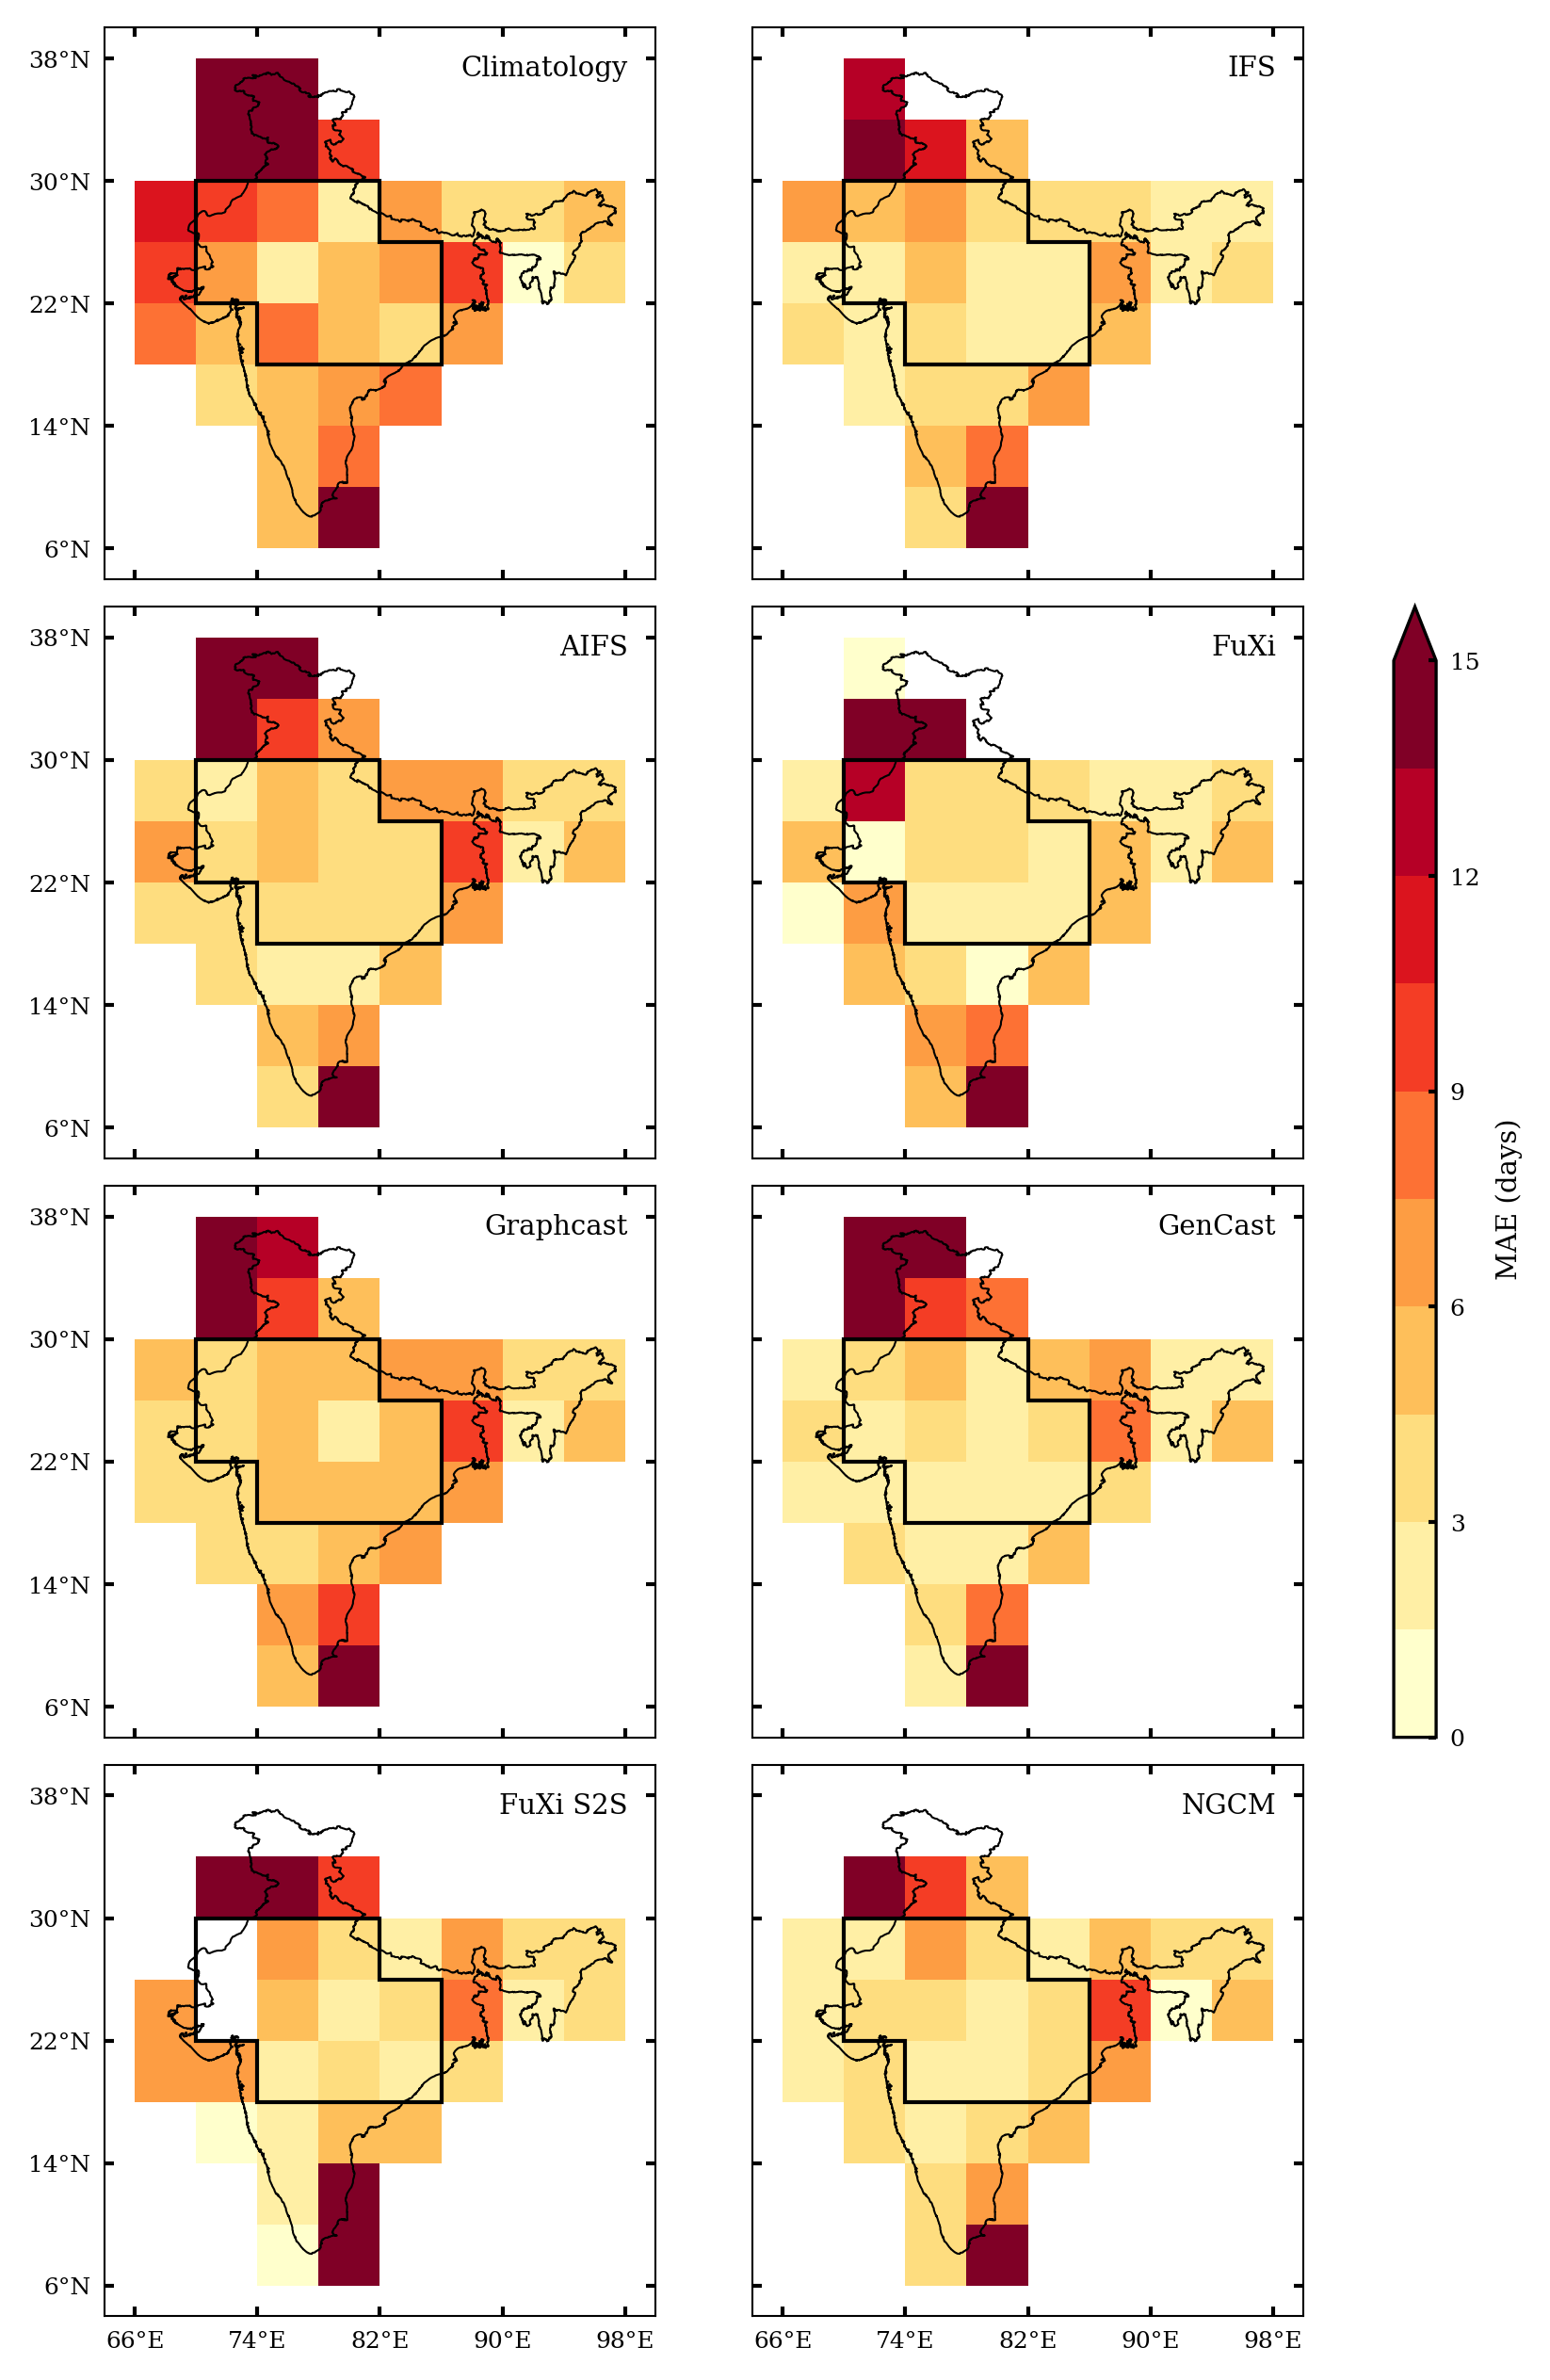

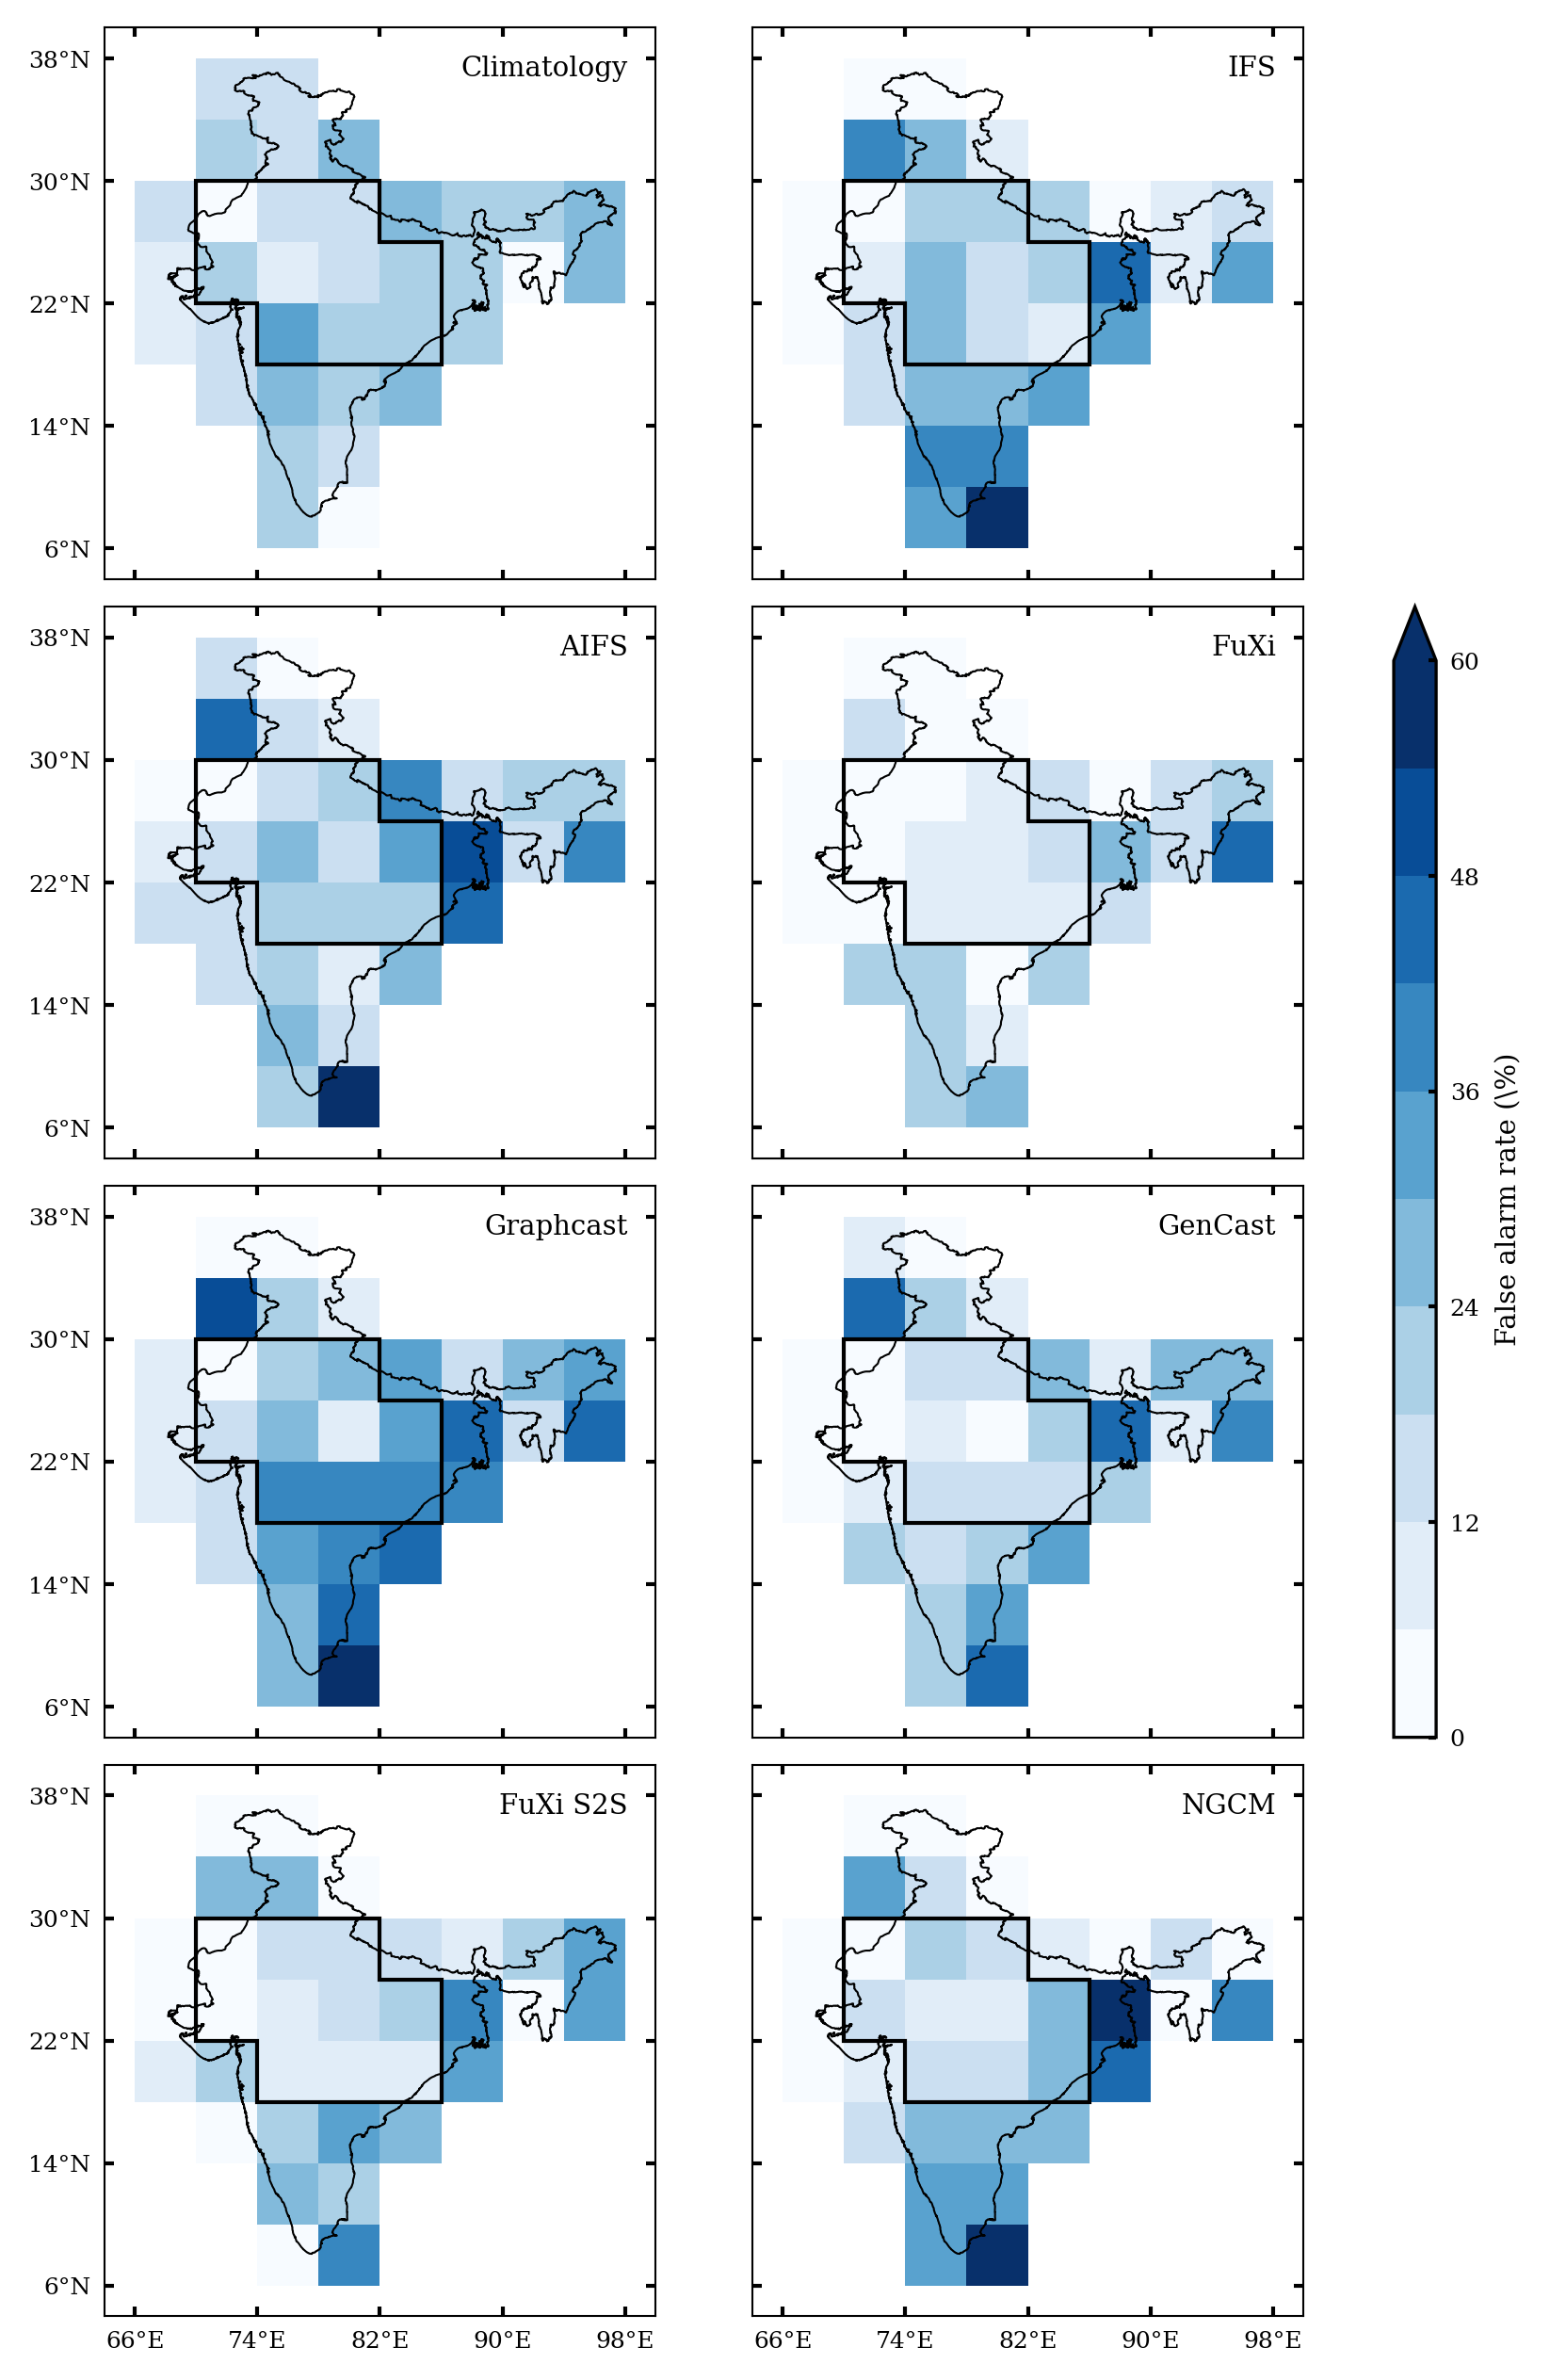

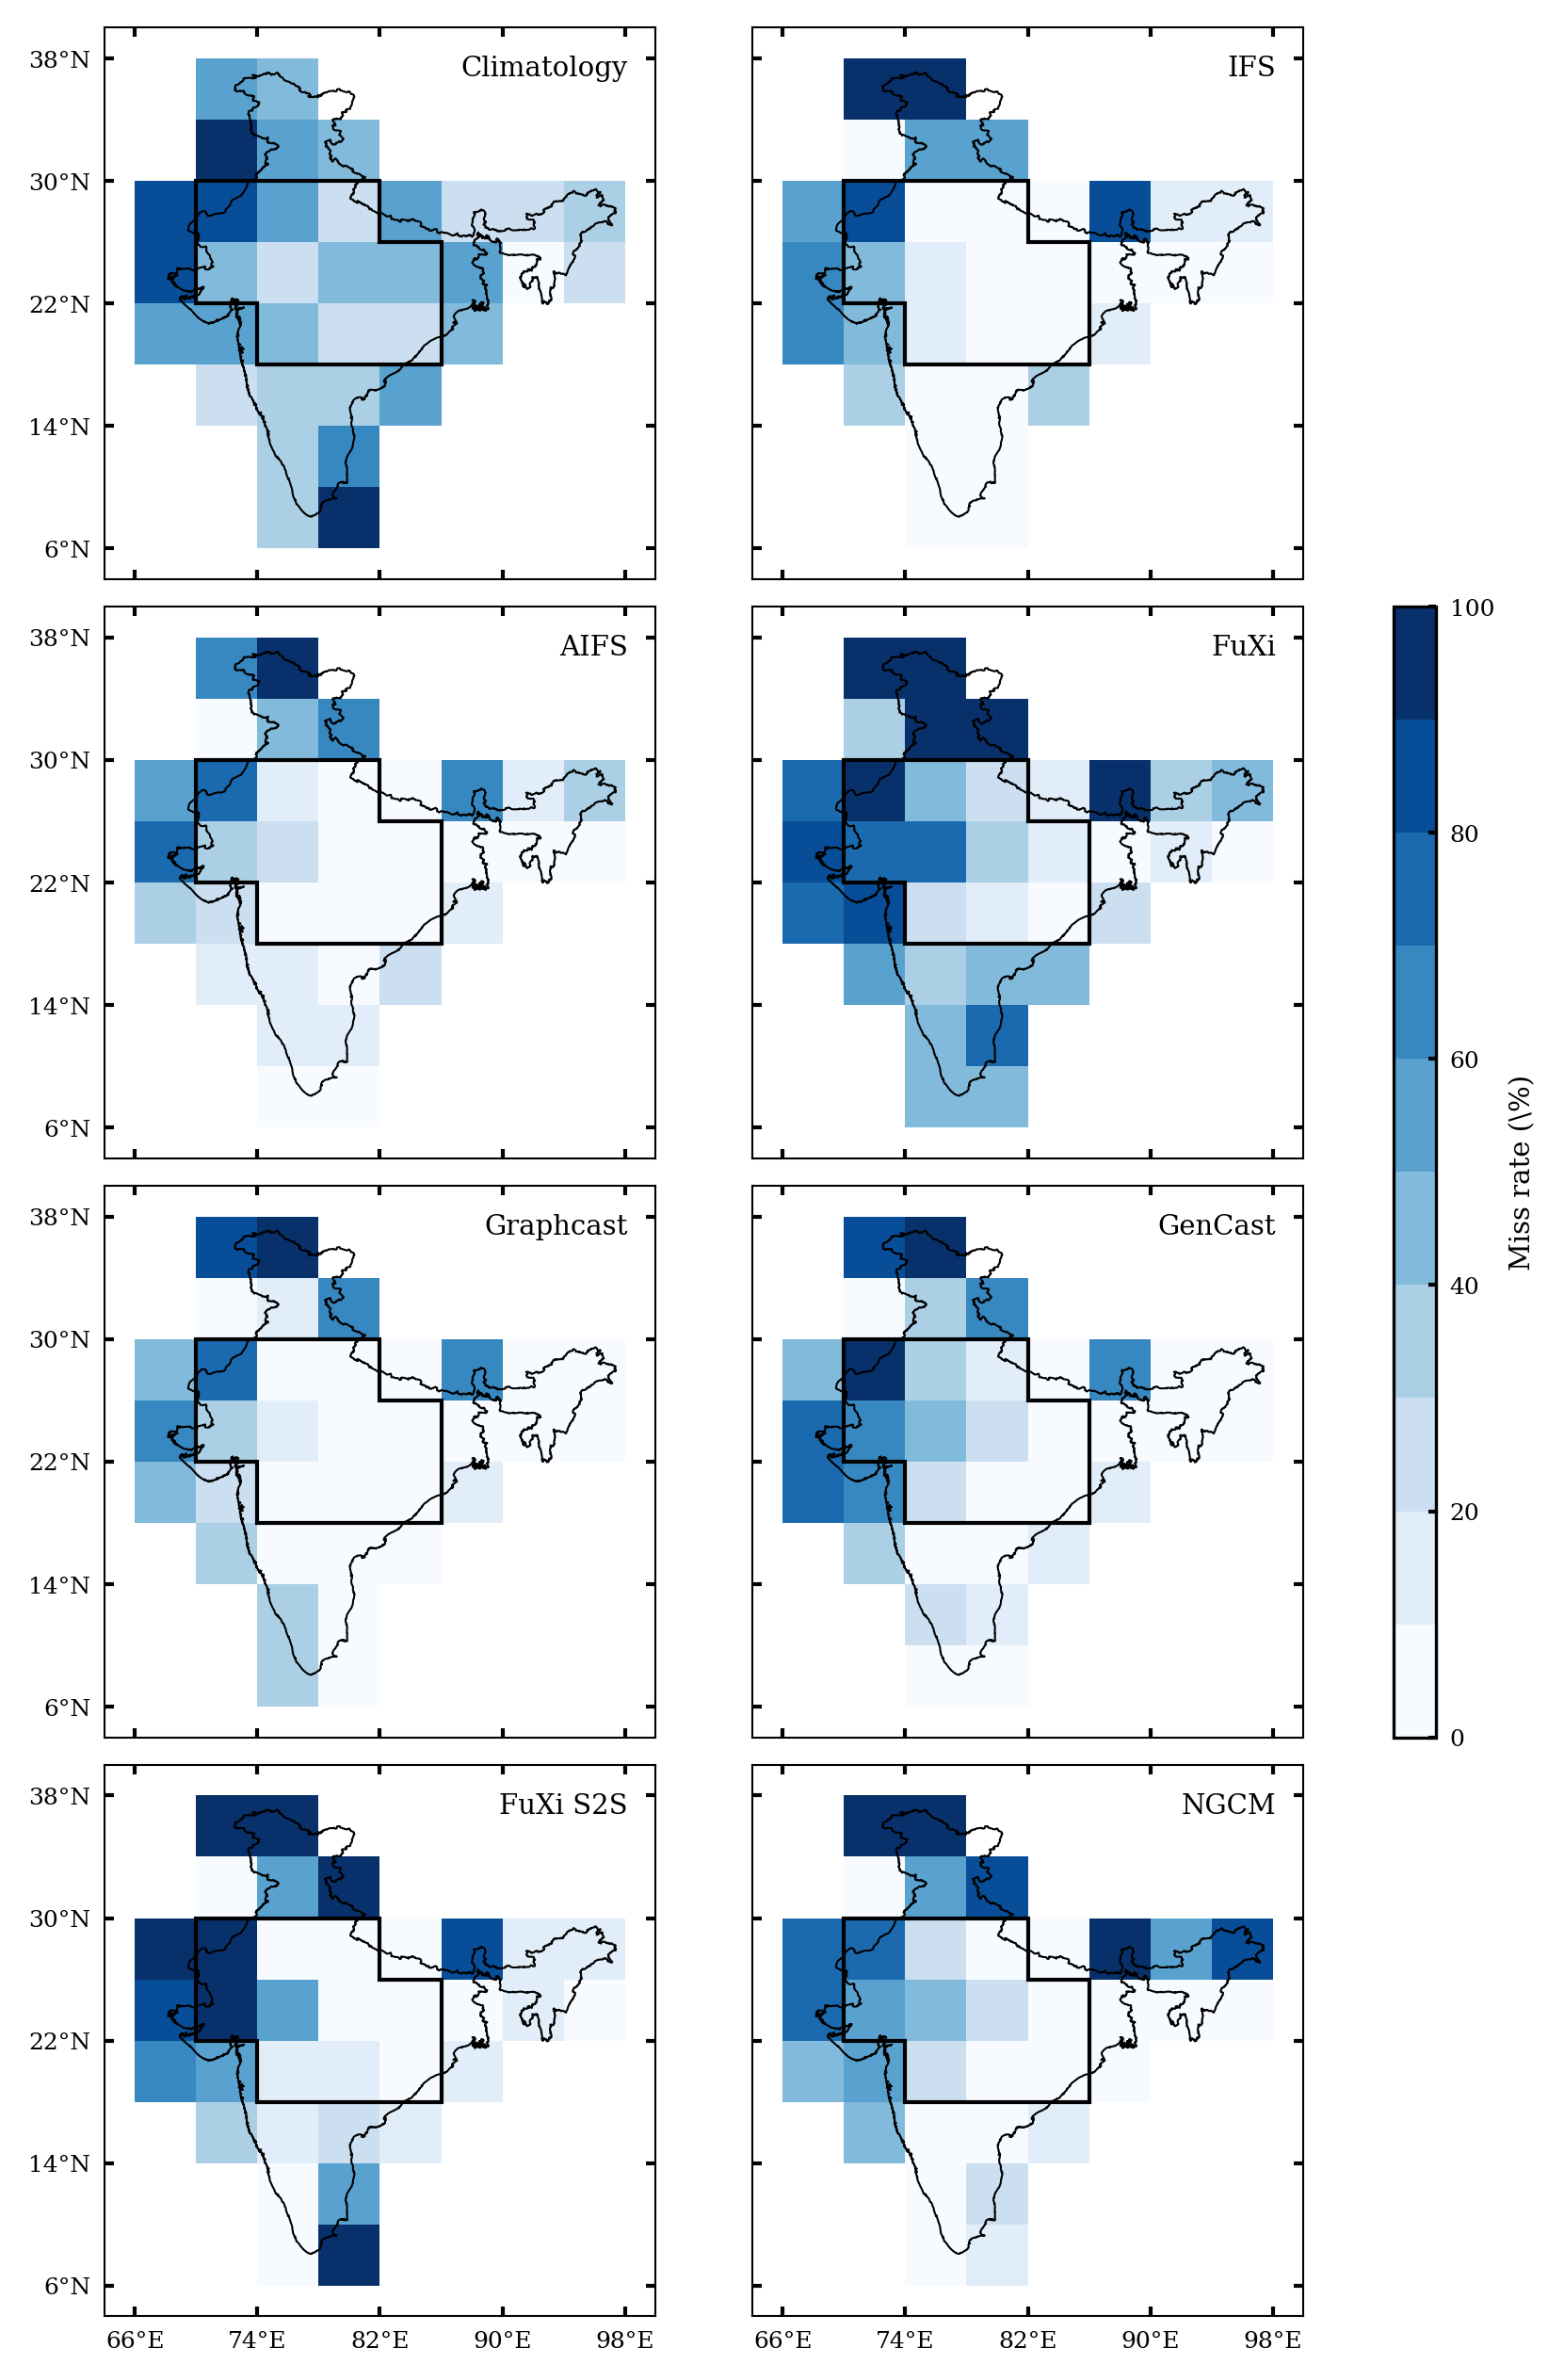

All 8-panel figures completed successfully!
8-panel figure functions created successfully!


In [233]:
panel_linewidth = 0.5  # Line width for panel borders
# Define plotting parameters
map_lw = 0.5
polygon_lw = 1
title_fontsize = 7
tick_length = 2.5
tick_width = 1
label_fontsize = SMALL_SIZE

# Define colors for MAE, FAR, and MR (matching your bar chart colors)
mae_col = np.array([217, 95, 14]) / 256  # Orange
far_col = np.array([49, 130, 189]) / 256  # Blue
mr_col = np.array([188, 189, 220]) / 256  # Light purple
# Create figures for MAE, FAR, and MR
if 'mae_avg' in locals():
    print("Creating 8-panel figures...")
    
    # MAE Figure - use YlOrRd colormap
    mae_fig = create_8_panel_figure(
        mae_avg, lon, lat,
        # mae_cmz, std_er, far_cmz, mr_cmz,
        data_type='MAE', vmin=0, vmax=15, cmap='YlOrRd', n_colors=10
    )
    
    # FAR Figure - use Blues colormap and multiply by 100
    far_fig = create_8_panel_figure(
        far, lon, lat,
        # far_cmz, std_er, far_cmz, mr_cmz,
        data_type='FAR', vmin=0, vmax=60, cmap='Blues', n_colors=10
    )
    
    # MR Figure - use Blues colormap and multiply by 100
    mr_fig = create_8_panel_figure(
        mr, lon, lat,
        # mr_cmz, std_er, far_cmz, mr_cmz,
        data_type='MR', vmin=0, vmax=100, cmap='Blues', n_colors=10
    )
    
    plt.show()
    print("All 8-panel figures completed successfully!")
    
else:
    print("Data not loaded yet. Please run the data loading cell first.")

print("8-panel figure functions created successfully!")